# BLOOD DONATION PREDICTION
## PRCP-1011-BloodDonaPred

In [2]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             roc_auc_score, f1_score, roc_curve, ConfusionMatrixDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import shap
 
print("All libraries imported successfully!")

All libraries imported successfully!


### Load Data

In [3]:
import pandas as pd

df = pd.read_excel(r"C:\Users\VIRAJ\Downloads\BDP\Data_Warm_Up_Predict_Blood_Donations_-_Traning_Data.xlsx")

#### Basic Checks

In [4]:
df.shape

(576, 6)

In [5]:
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


### Data Cleaning

In [6]:
# Drop irrelevant column
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)
 
print("\nNull values:\n", df.isnull().sum())
print(f"\nDuplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)
print(f"Shape after removing duplicates: {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nDescriptive stats:\n{df.describe()}")


Null values:
 Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

Duplicates found: 153
Shape after removing duplicates: (423, 5)

Data types:
Months since Last Donation     int64
Number of Donations            int64
Total Volume Donated (c.c.)    int64
Months since First Donation    int64
Made Donation in March 2007    int64
dtype: object

Descriptive stats:
       Months since Last Donation  Number of Donations  \
count                  423.000000           423.000000   
mean                     9.482270             6.716312   
std                      8.347548             6.135507   
min                      0.000000             1.000000   
25%                      3.000000             3.000000   
50%                      8.000000             5.000000   
75%                     14.000000             8.000000   
max                     74.000000            5

### EDA

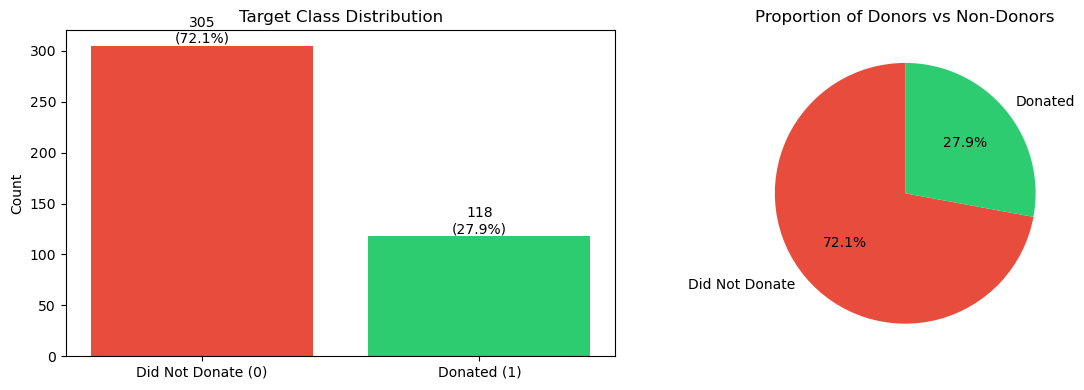

In [7]:
TARGET = "Made Donation in March 2007"
 
# ---  Target Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df[TARGET].value_counts()
axes[0].bar(["Did Not Donate (0)", "Donated (1)"], counts.values, color=["#e74c3c", "#2ecc71"])
axes[0].set_title("Target Class Distribution")
axes[0].set_ylabel("Count")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, f"{v}\n({v/len(df)*100:.1f}%)", ha='center')
 
axes[1].pie(counts.values, labels=["Did Not Donate", "Donated"],
            autopct='%1.1f%%', colors=["#e74c3c", "#2ecc71"], startangle=90)
axes[1].set_title("Proportion of Donors vs Non-Donors")
plt.tight_layout()
plt.savefig("01_target_distribution.png", dpi=150, bbox_inches='tight')
plt.show()

### Feature Distributions

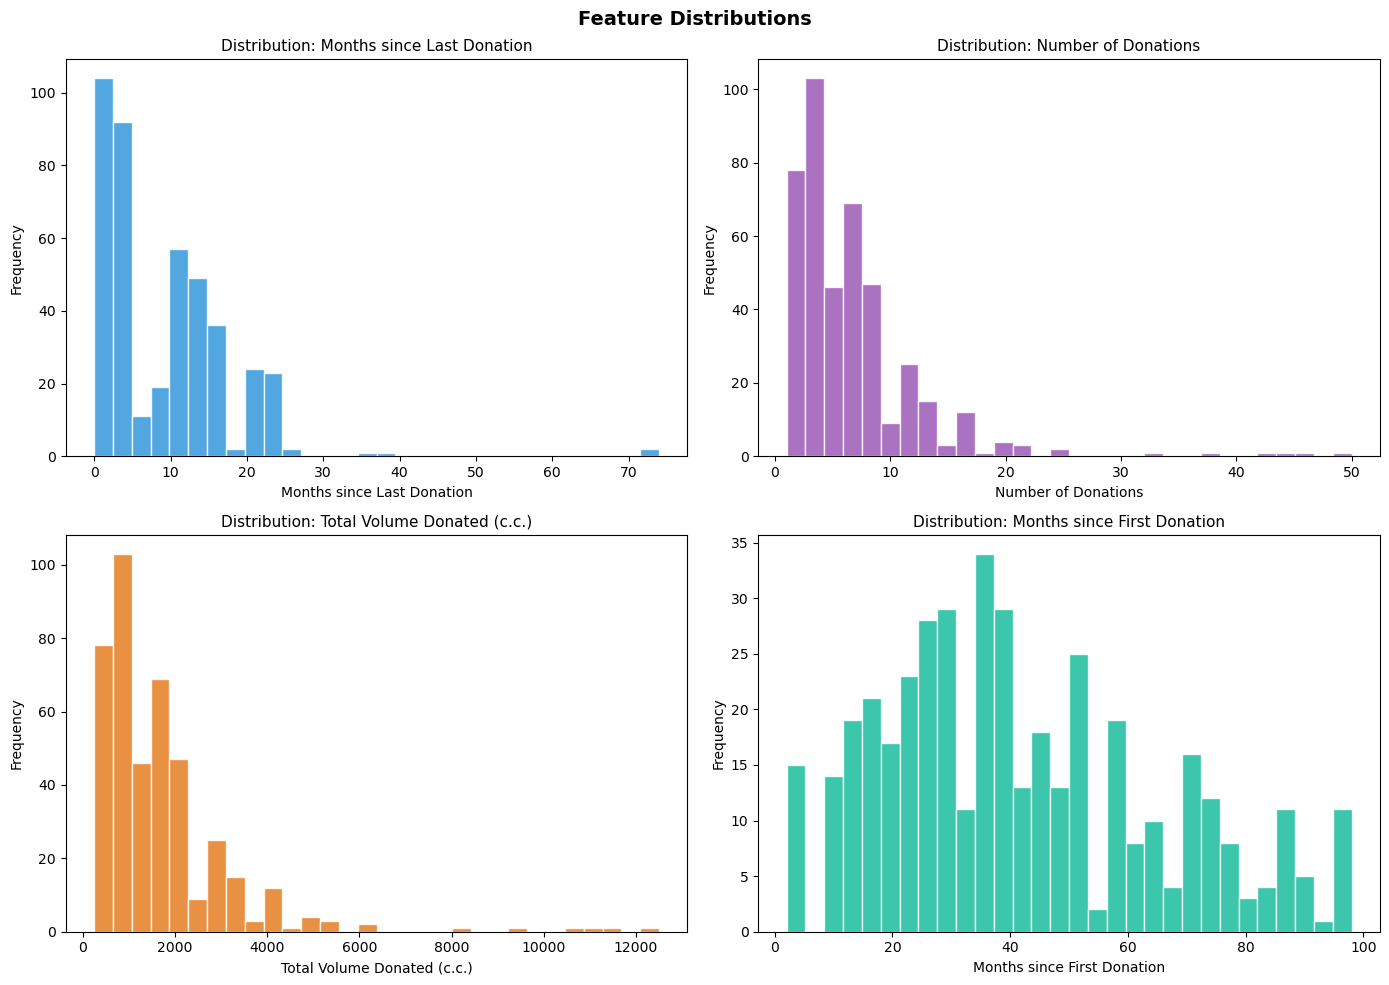

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
features = [c for c in df.columns if c != TARGET]
colors = ["#3498db", "#9b59b6", "#e67e22", "#1abc9c"]
for i, (col, color) in enumerate(zip(features, colors)):
    ax = axes[i // 2][i % 2]
    ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(f"Distribution: {col}", fontsize=11)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.suptitle("Feature Distributions", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("02_feature_distributions.png", dpi=150, bbox_inches='tight')
plt.show()

### Boxplots by Target

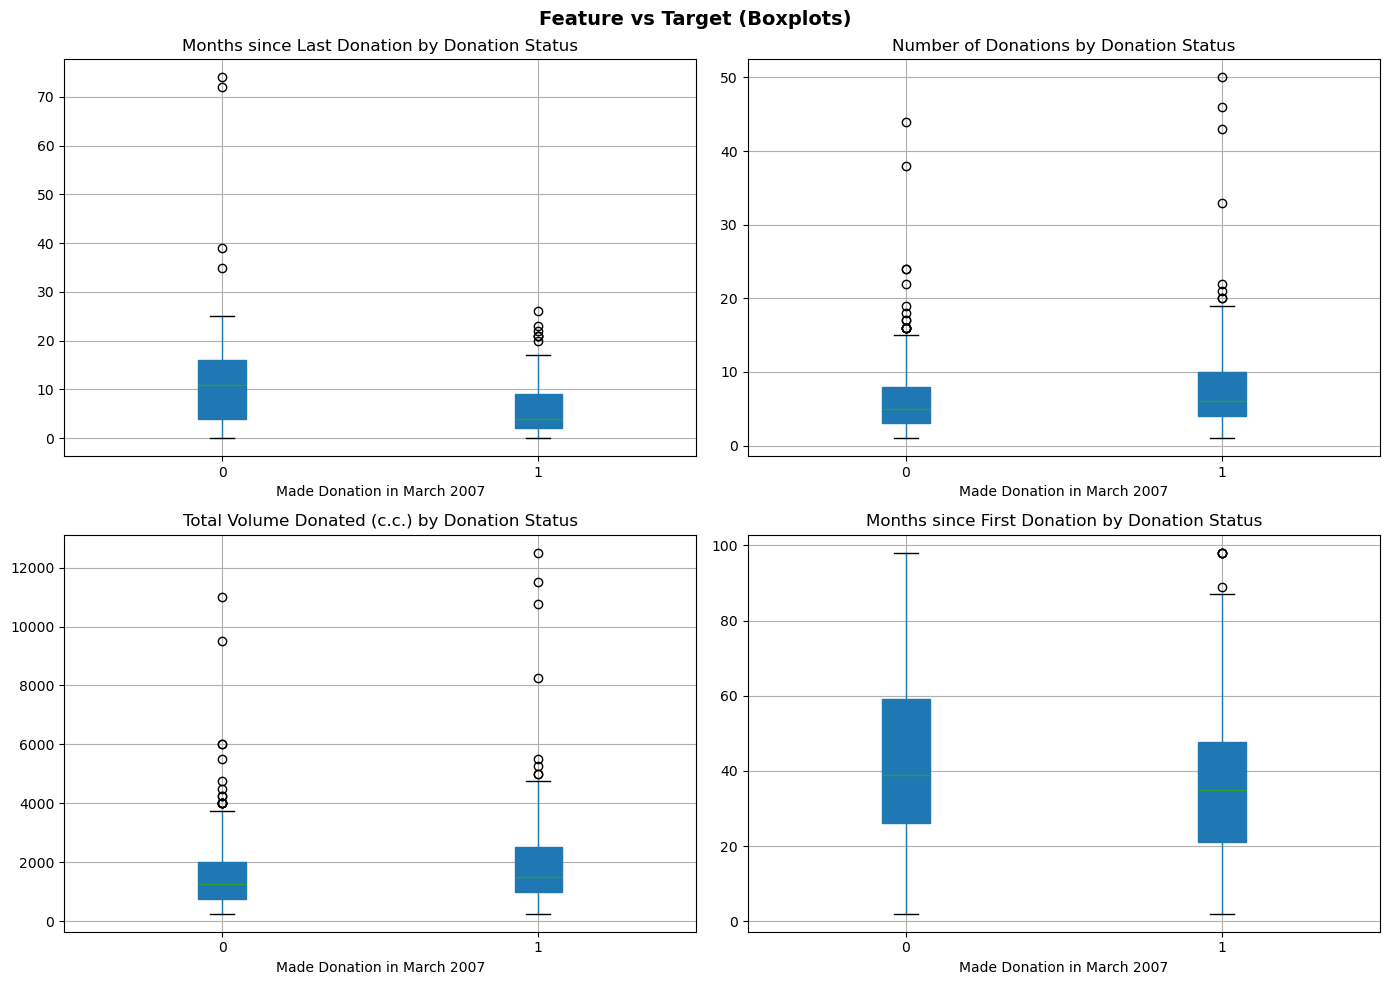

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(features):
    ax = axes[i // 2][i % 2]
    df.boxplot(column=col, by=TARGET, ax=ax, patch_artist=True)
    ax.set_title(f"{col} by Donation Status")
    ax.set_xlabel("Made Donation in March 2007")
plt.suptitle("Feature vs Target (Boxplots)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("03_boxplots_by_target.png", dpi=150, bbox_inches='tight')
plt.show()

### Correlation Heatmap

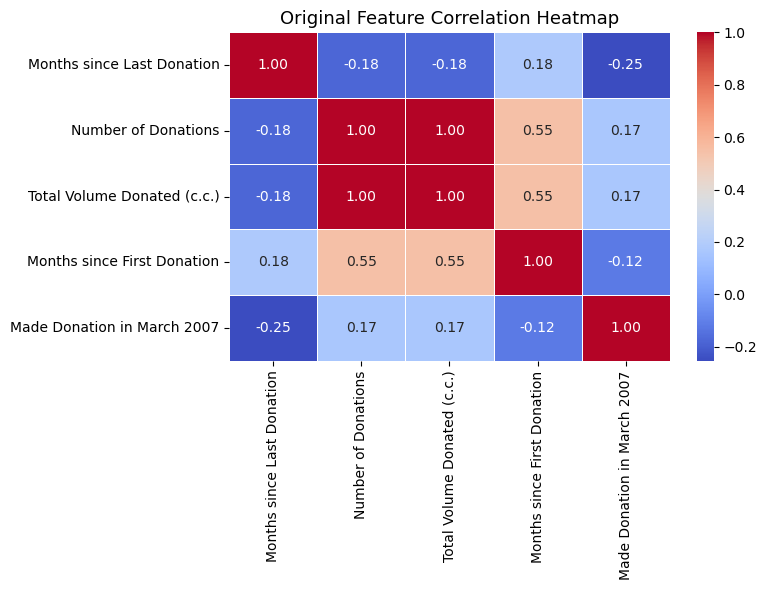

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 10})
plt.title("Original Feature Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("04_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# NOTE: Total Volume Donated is perfectly correlated (r=1.0) with Number of Donations
# → It is redundant and will be dropped

### FEATURE ENGINEERING

In [12]:
df_fe = df.copy()
 
# Drop edundant (perfectly collinear) feature
df_fe.drop("Total Volume Donated (c.c.)", axis=1, inplace=True)
 
# Behavioral engineered features
df_fe["Donation_Frequency"] = (
    df_fe["Number of Donations"] /
    (df_fe["Months since First Donation"] + 1)   # +1 avoids div-by-zero
)
 
df_fe["Recency_Ratio"] = (
    df_fe["Months since Last Donation"] /
    (df_fe["Months since First Donation"] + 1)
)
 
df_fe["Donation_Momentum"] = (
    df_fe["Donation_Frequency"] /
    (df_fe["Months since Last Donation"] + 1)
)
 
df_fe["Recent_Donor"] = (df_fe["Months since Last Donation"] <= 6).astype(int)
 
df_fe["Engagement_Score"] = (
    df_fe["Donation_Frequency"] * 100 - df_fe["Recency_Ratio"] * 10
)
 
print("New feature columns:", df_fe.columns.tolist())

New feature columns: ['Months since Last Donation', 'Number of Donations', 'Months since First Donation', 'Made Donation in March 2007', 'Donation_Frequency', 'Recency_Ratio', 'Donation_Momentum', 'Recent_Donor', 'Engagement_Score']


### Post FE Correlation

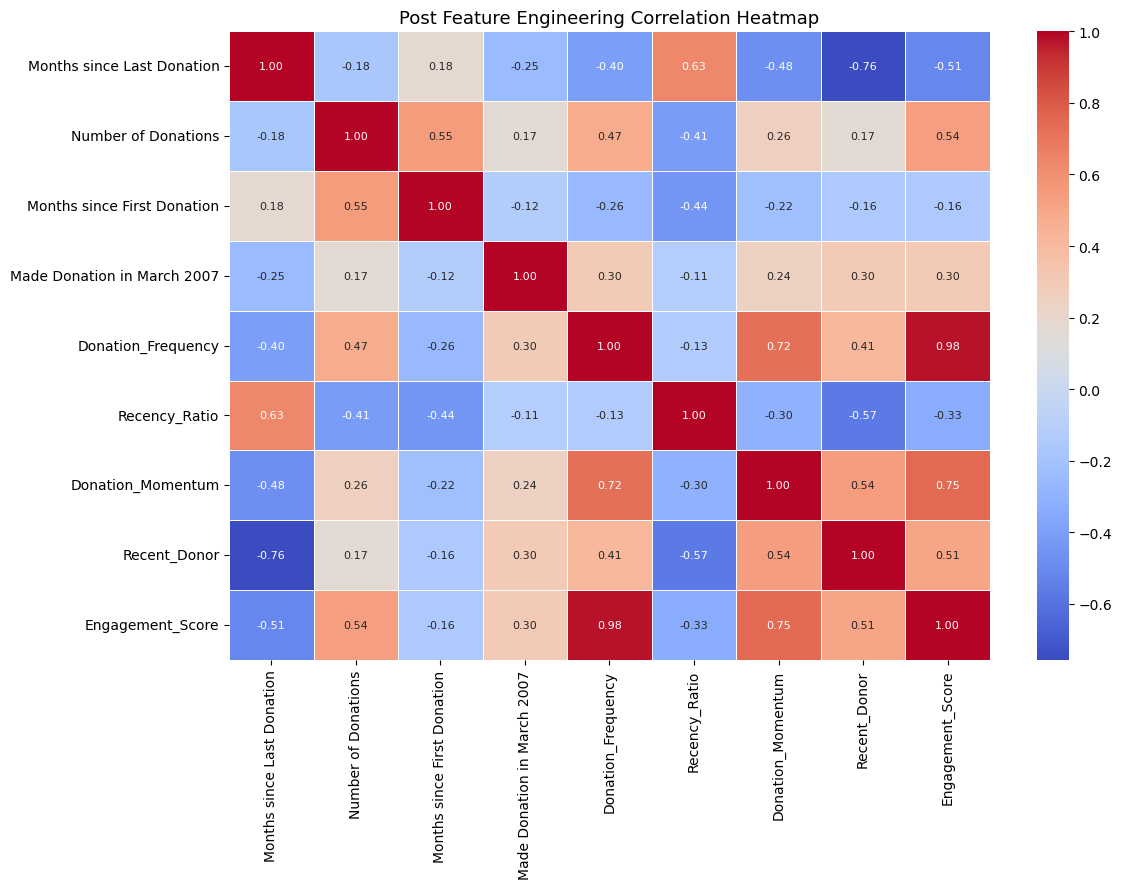

Final features: ['Months since Last Donation', 'Number of Donations', 'Made Donation in March 2007', 'Donation_Momentum', 'Recent_Donor', 'Engagement_Score']


In [13]:
plt.figure(figsize=(12, 9))
sns.heatmap(df_fe.corr(), annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, annot_kws={"size": 8})
plt.title("Post Feature Engineering Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig("05_fe_correlation_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

# Final feature selection: drop multicollinear or weak features
DROP_COLS = ["Months since First Donation", "Recency_Ratio", "Donation_Frequency"]
df_final = df_fe.drop(columns=DROP_COLS)
print("Final features:", df_final.columns.tolist())

### TRAIN-TEST SPLIT

In [14]:
X = df_final.drop(TARGET, axis=1)
y = df_final[TARGET]
 
print(f"\nClass distribution in y:\n{y.value_counts()}")
print(f"Class imbalance ratio: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
 
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Class distribution in y:
Made Donation in March 2007
0    305
1    118
Name: count, dtype: int64
Class imbalance ratio: 2.58:1


### MODEL TRAINING & EVALUATION

In [15]:
# Utility function to evaluate any model
results = {}
 
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te, proba=True):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1] if proba else None
    auc = roc_auc_score(y_te, y_prob) if proba else roc_auc_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    acc = accuracy_score(y_te, y_pred)
    cr = classification_report(y_te, y_pred, output_dict=True)
    prec = cr["1"]["precision"]
    rec = cr["1"]["recall"]
    print(f"\n{'='*50}")
    print(f"MODEL: {name}")
    print(f"{'='*50}")
    print(classification_report(y_te, y_pred))
    print(f"ROC-AUC: {auc:.4f}")
    results[name] = {
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(auc, 4),
        "y_prob": y_prob
    }
    return model

##### Logistic Regression

In [16]:
lr = evaluate_model(
    "Logistic Regression",
    LogisticRegression(class_weight='balanced', max_iter=1000, C=0.1),
    X_train_sc, X_test_sc, y_train, y_test
)


MODEL: Logistic Regression
              precision    recall  f1-score   support

           0       0.85      0.64      0.73        61
           1       0.44      0.71      0.54        24

    accuracy                           0.66        85
   macro avg       0.64      0.67      0.63        85
weighted avg       0.73      0.66      0.68        85

ROC-AUC: 0.7548


##### Random Forest

In [17]:
rf = evaluate_model(
    "Random Forest",
    RandomForestClassifier(n_estimators=200, class_weight='balanced',
                           max_depth=6, random_state=42),
    X_train, X_test, y_train, y_test
)


MODEL: Random Forest
              precision    recall  f1-score   support

           0       0.81      0.79      0.80        61
           1       0.50      0.54      0.52        24

    accuracy                           0.72        85
   macro avg       0.66      0.66      0.66        85
weighted avg       0.73      0.72      0.72        85

ROC-AUC: 0.7329


##### SVM (with Calibration for proper probabilities)

In [18]:
svm_base = SVC(kernel='rbf', class_weight='balanced', random_state=42, C=1.0, gamma='scale')
svm_cal = CalibratedClassifierCV(svm_base, cv=5)
svm_cal = evaluate_model(
    "SVM (Calibrated)",
    svm_cal,
    X_train_sc, X_test_sc, y_train, y_test
)


MODEL: SVM (Calibrated)
              precision    recall  f1-score   support

           0       0.72      1.00      0.84        61
           1       0.00      0.00      0.00        24

    accuracy                           0.72        85
   macro avg       0.36      0.50      0.42        85
weighted avg       0.52      0.72      0.60        85

ROC-AUC: 0.7828


##### -----XGBoost with GridSearchCV ──

In [19]:
xgb_param = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'scale_pos_weight': [3]   # handles imbalance
}
xgb_grid = GridSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', use_label_encoder=False),
    xgb_param, cv=skf, scoring='roc_auc', n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
best_xgb = xgb_grid.best_estimator_
print(f"\nBest XGBoost params: {xgb_grid.best_params_}")
evaluate_model("XGBoost (Tuned)", best_xgb, X_train, X_test, y_train, y_test)


Best XGBoost params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'scale_pos_weight': 3}

MODEL: XGBoost (Tuned)
              precision    recall  f1-score   support

           0       0.83      0.66      0.73        61
           1       0.43      0.67      0.52        24

    accuracy                           0.66        85
   macro avg       0.63      0.66      0.63        85
weighted avg       0.72      0.66      0.67        85

ROC-AUC: 0.7073


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=3, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

##### ---CatBoost ──

In [20]:
cat = evaluate_model(
    "CatBoost",
    CatBoostClassifier(depth=4, learning_rate=0.05, iterations=300,
                       random_state=42, verbose=0, auto_class_weights='Balanced'),
    X_train, X_test, y_train, y_test
)


MODEL: CatBoost
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        61
           1       0.47      0.58      0.52        24

    accuracy                           0.69        85
   macro avg       0.64      0.66      0.65        85
weighted avg       0.72      0.69      0.70        85

ROC-AUC: 0.6940


### SMOTE EXPERIMENT (Proper Pipeline)

In [21]:
smote_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42, k_neighbors=3)),
    ('model', XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                             random_state=42, eval_metric='logloss', use_label_encoder=False))
])
smote_pipeline.fit(X_train, y_train)
y_pred_smote = smote_pipeline.predict(X_test)
y_prob_smote = smote_pipeline.predict_proba(X_test)[:, 1]
auc_smote = roc_auc_score(y_test, y_prob_smote)
print(f"\n{'='*50}")
print(f"MODEL: XGBoost + SMOTE Pipeline")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_smote))
print(f"ROC-AUC: {auc_smote:.4f}")
results["XGBoost + SMOTE"] = {
    "Accuracy": round(accuracy_score(y_test, y_pred_smote), 4),
    "Precision": round(f1_score(y_test, y_pred_smote, output_dict=True)["1"]["precision"] if hasattr(f1_score(y_test, y_pred_smote), '__iter__') else 0, 4),
    "Recall": round(classification_report(y_test, y_pred_smote, output_dict=True)["1"]["recall"], 4),
    "F1-Score": round(f1_score(y_test, y_pred_smote), 4),
    "ROC-AUC": round(auc_smote, 4),
    "y_prob": y_prob_smote
}


MODEL: XGBoost + SMOTE Pipeline
              precision    recall  f1-score   support

           0       0.79      0.72      0.75        61
           1       0.41      0.50      0.45        24

    accuracy                           0.66        85
   macro avg       0.60      0.61      0.60        85
weighted avg       0.68      0.66      0.67        85

ROC-AUC: 0.6728


### SOFT VOTING ENSEMBLE (Best Models)

In [22]:
ensemble = VotingClassifier(
    estimators=[
        ('svm', svm_cal),
        ('xgb', best_xgb),
        ('cat', cat)
    ],
    voting='soft'
)
ensemble.fit(
    pd.concat([
        pd.DataFrame(X_train_sc, columns=X_train.columns),
        pd.DataFrame(X_train, columns=X_train.columns)
    ]).iloc[:len(X_train)],   # svm needs scaled; for simplicity train on unscaled
    y_train
)
 
# ── Simpler: manual soft voting ──
svm_prob = results["SVM (Calibrated)"]["y_prob"]
xgb_prob = results["XGBoost (Tuned)"]["y_prob"]
cat_prob = results["CatBoost"]["y_prob"]
 
# Weighted average (SVM slightly lower weight due to scaling dependency)
ensemble_prob = (svm_prob * 0.3 + xgb_prob * 0.4 + cat_prob * 0.3)
y_pred_ens = (ensemble_prob >= 0.5).astype(int)
auc_ens = roc_auc_score(y_test, ensemble_prob)
f1_ens = f1_score(y_test, y_pred_ens)
acc_ens = accuracy_score(y_test, y_pred_ens)
cr_ens = classification_report(y_test, y_pred_ens, output_dict=True)
 
print(f"\n{'='*50}")
print(f"MODEL: Soft Voting Ensemble (SVM+XGB+CatBoost)")
print(f"{'='*50}")
print(classification_report(y_test, y_pred_ens))
print(f"ROC-AUC: {auc_ens:.4f}")
 
results["Soft Voting Ensemble"] = {
    "Accuracy": round(acc_ens, 4),
    "Precision": round(cr_ens["1"]["precision"], 4),
    "Recall": round(cr_ens["1"]["recall"], 4),
    "F1-Score": round(f1_ens, 4),
    "ROC-AUC": round(auc_ens, 4),
    "y_prob": ensemble_prob
}


MODEL: Soft Voting Ensemble (SVM+XGB+CatBoost)
              precision    recall  f1-score   support

           0       0.82      0.77      0.80        61
           1       0.50      0.58      0.54        24

    accuracy                           0.72        85
   macro avg       0.66      0.68      0.67        85
weighted avg       0.73      0.72      0.72        85

ROC-AUC: 0.7199


### MODEL COMPARISON TABLE


MODEL COMPARISON REPORT
                      Accuracy  Precision  Recall  F1-Score  ROC-AUC
SVM (Calibrated)        0.7176     0.0000  0.0000    0.0000   0.7828
Logistic Regression     0.6588     0.4359  0.7083    0.5397   0.7548
Random Forest           0.7176     0.5000  0.5417    0.5200   0.7329
Soft Voting Ensemble    0.7176     0.5000  0.5833    0.5385   0.7199
XGBoost (Tuned)         0.6588     0.4324  0.6667    0.5246   0.7073
CatBoost                0.6941     0.4667  0.5833    0.5185   0.6940
XGBoost + SMOTE         0.6588     0.0000  0.5000    0.4528   0.6728


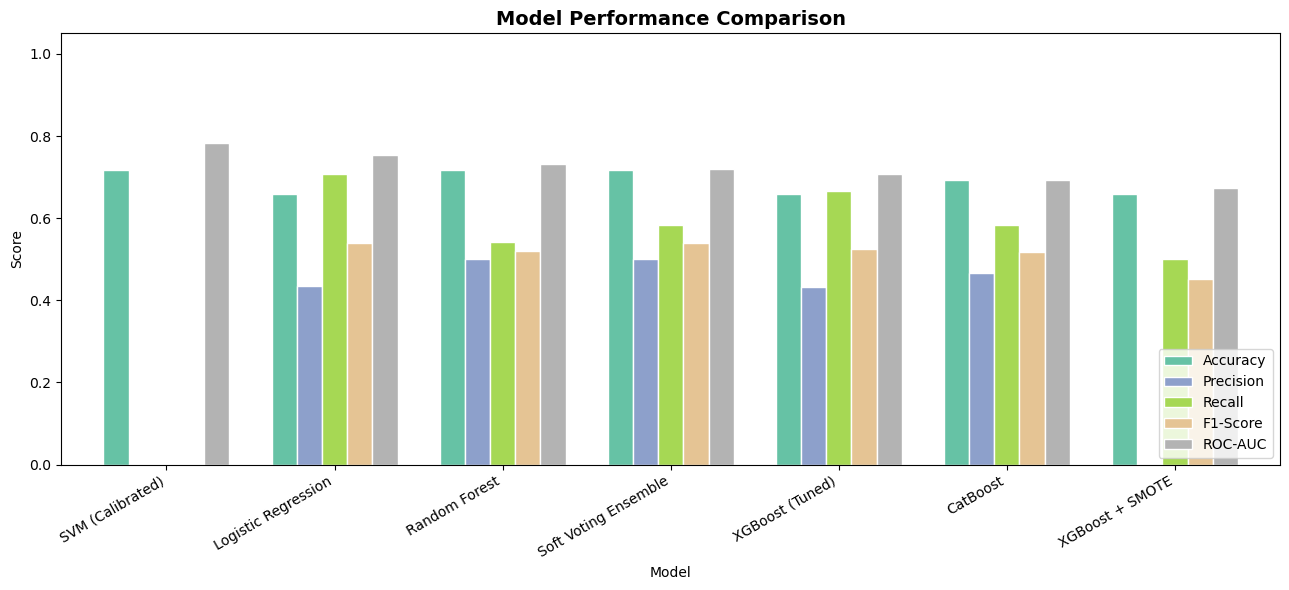

In [23]:
comparison_df = pd.DataFrame({
    k: {m: v for m, v in vals.items() if m != "y_prob"}
    for k, vals in results.items()
}).T.sort_values("ROC-AUC", ascending=False)
 
print("\n" + "="*70)
print("MODEL COMPARISON REPORT")
print("="*70)
print(comparison_df.to_string())
 
# Bar chart comparison
fig, ax = plt.subplots(figsize=(13, 6))
comparison_df[["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]].plot(
    kind='bar', ax=ax, colormap='Set2', edgecolor='white', width=0.75
)
ax.set_title("Model Performance Comparison", fontsize=14, fontweight='bold')
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
ax.legend(loc='lower right')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("06_model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

### ROC CURVE COMPARISON

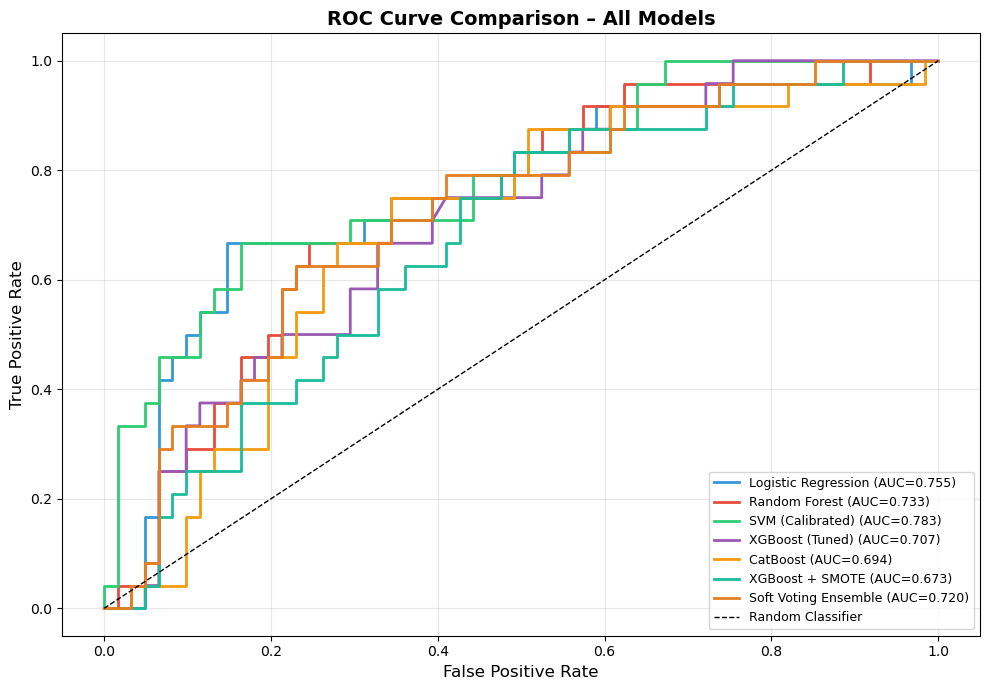

In [24]:
plt.figure(figsize=(10, 7))
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6', '#f39c12', '#1abc9c', '#e67e22']
for (name, vals), color in zip(results.items(), colors):
    if vals["y_prob"] is not None:
        fpr, tpr, _ = roc_curve(y_test, vals["y_prob"])
        plt.plot(fpr, tpr, label=f"{name} (AUC={vals['ROC-AUC']:.3f})", color=color, lw=2)
plt.plot([0,1],[0,1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve Comparison – All Models", fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("07_roc_curves.png", dpi=150, bbox_inches='tight')
plt.show()

### CONFUSION MATRICES


Best model: SVM (Calibrated) (ROC-AUC=0.7828)


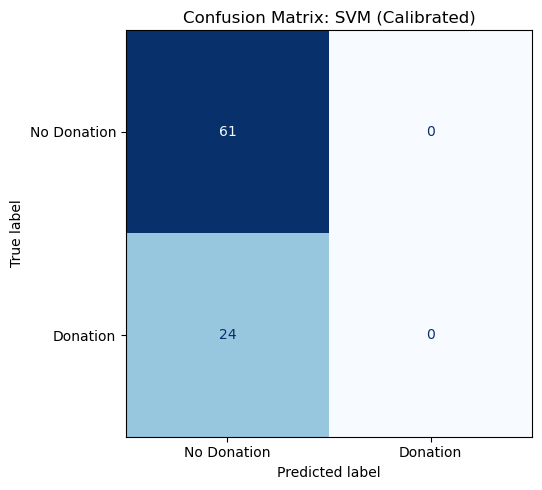

In [25]:
best_model_name = comparison_df.index[0]
print(f"\nBest model: {best_model_name} (ROC-AUC={comparison_df.iloc[0]['ROC-AUC']})")
 
# Plot confusion matrix for best model
best_prob = results[best_model_name]["y_prob"]
best_pred = (best_prob >= 0.5).astype(int)
cm = confusion_matrix(y_test, best_pred)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Donation", "Donation"])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f"Confusion Matrix: {best_model_name}", fontsize=12)
plt.tight_layout()
plt.savefig("08_confusion_matrix_best.png", dpi=150, bbox_inches='tight')
plt.show()

### FEATURE IMPORTANCE (SHAP)


Generating SHAP feature importance for XGBoost...


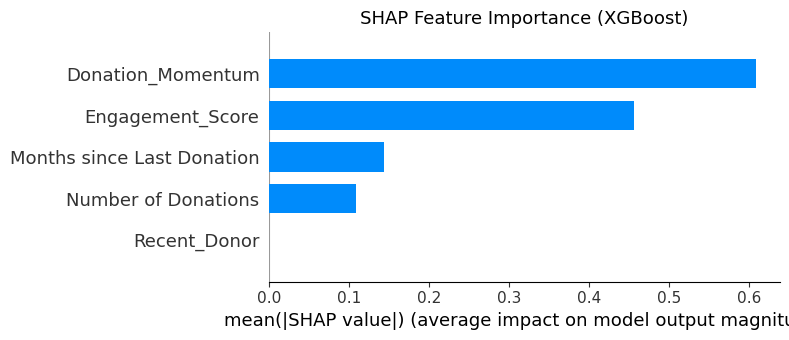

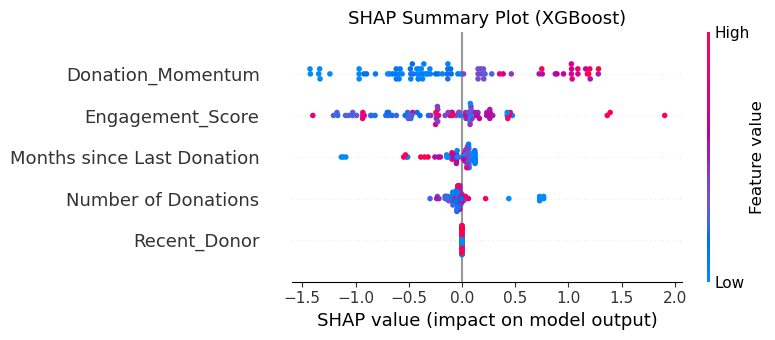

In [26]:
print("\nGenerating SHAP feature importance for XGBoost...")
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test)
 
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Feature Importance (XGBoost)", fontsize=13)
plt.tight_layout()
plt.savefig("09_shap_feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()
 
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot (XGBoost)", fontsize=13)
plt.tight_layout()
plt.savefig("10_shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

#### THRESHOLD TUNING

In [27]:
print("\nThreshold tuning for best ensemble model:")
thresholds = np.arange(0.30, 0.70, 0.05)
threshold_results = []
for t in thresholds:
    preds = (ensemble_prob >= t).astype(int)
    threshold_results.append({
        "Threshold": round(t, 2),
        "F1": round(f1_score(y_test, preds), 4),
        "Recall": round(classification_report(y_test, preds, output_dict=True)["1"]["recall"], 4),
        "Precision": round(classification_report(y_test, preds, output_dict=True)["1"]["precision"], 4),
        "ROC-AUC": round(roc_auc_score(y_test, ensemble_prob), 4)
    })
 
thr_df = pd.DataFrame(threshold_results)
print(thr_df.to_string(index=False))
 
best_thr = thr_df.loc[thr_df["F1"].idxmax(), "Threshold"]
print(f"\nOptimal threshold (max F1): {best_thr}")


Threshold tuning for best ensemble model:
 Threshold     F1  Recall  Precision  ROC-AUC
      0.30 0.5278  0.7917     0.3958   0.7199
      0.35 0.5455  0.7500     0.4286   0.7199
      0.40 0.5333  0.6667     0.4444   0.7199
      0.45 0.5357  0.6250     0.4688   0.7199
      0.50 0.5385  0.5833     0.5000   0.7199
      0.55 0.4444  0.4167     0.4762   0.7199
      0.60 0.4211  0.3333     0.5714   0.7199
      0.65 0.4000  0.2917     0.6364   0.7199

Optimal threshold (max F1): 0.35


#### PREDICTION FUNCTION (Production Use)

In [28]:
def predict_donor(months_since_last, num_donations, months_since_first, threshold=best_thr):
    """
    Predict whether a donor will donate in March 2007.
    
    Parameters:
        months_since_last   : int - months since last donation
        num_donations       : int - total number of donations
        months_since_first  : int - months since first donation
        threshold           : float - classification threshold (default from tuning)
    
    Returns:
        dict with prediction and probability
    """
    freq = num_donations / (months_since_first + 1)
    momentum = freq / (months_since_last + 1)
    recent = int(months_since_last <= 6)
    engagement = freq * 100 - (months_since_last / (months_since_first + 1)) * 10
 
    features = pd.DataFrame([{
        "Months since Last Donation": months_since_last,
        "Number of Donations": num_donations,
        "Donation_Momentum": momentum,
        "Recent_Donor": recent,
        "Engagement_Score": engagement
    }])
 
    # Ensemble probabilities
    svm_p = svm_cal.predict_proba(scaler.transform(features))[:, 1][0]
    xgb_p = best_xgb.predict_proba(features)[:, 1][0]
    cat_p = cat.predict_proba(features)[:, 1][0]
    prob = svm_p * 0.3 + xgb_p * 0.4 + cat_p * 0.3
    will_donate = int(prob >= threshold)
 
    return {
        "Probability of Donating": round(float(prob), 4),
        "Prediction": "Will Donate ✅" if will_donate else "Will NOT Donate ❌",
        "Threshold Used": threshold
    }
 
# Example predictions
print("\n=== SAMPLE PREDICTIONS ===")
print(predict_donor(months_since_last=2, num_donations=10, months_since_first=36))
print(predict_donor(months_since_last=15, num_donations=2, months_since_first=20))


=== SAMPLE PREDICTIONS ===
{'Probability of Donating': 0.7418, 'Prediction': 'Will Donate ✅', 'Threshold Used': np.float64(0.35)}
{'Probability of Donating': 0.3525, 'Prediction': 'Will Donate ✅', 'Threshold Used': np.float64(0.35)}


#### Final Report